#***<p style="text-align:center; color:green; font-size:100px;">
🏭 Steel Plant Production & Operational Analysis</p>***

![](SteelPlant.png)

#***<p style="text-align:center; color:green; font-size:50px;">
🏭 Steel Plant Production & Operations Analysis: Analyzing Production, Downtime, Quality, Machines, Operators, and Operational Performance </p>***

# ***This project focuses on exploring and analyzing a Steel Plant Production Dataset through a systematic and analytical approach. The analysis begins with data cleaning, preprocessing, and validation to ensure accuracy, consistency, and reliability of production, machine, operator, downtime, and quality-related data. Further, SQL and Python-based exploratory data analysis techniques are used to examine production performance, downtime patterns, machine utilization, defect quantities, operator performance, and departmental trends across different shifts and time periods. Statistical analysis and data visualizations are applied to identify important patterns, variations, and operational trends.The analysis also includes segmentation of data based on departments, production shifts, machines, operators, product categories, and production dates. Key performance indicators such as total production, total downtime, defect quantity, defect rate, production efficiency, and machine performance are analyzed to understand operational performance and identify areas requiring attention. Finally, the project presents meaningful insights through interactive dashboards and visualizations, helping to understand production trends, quality issues, downtime behavior, and overall plant performance. The analysis demonstrates how data-driven techniques can support operational monitoring and informed decision-making in a manufacturing environment.***

# ***<p style="text-align: center;color: green; font-size: 70px ;"> Business Problem</p>***

# ***The main problem of this project is to understand the **overall performance of a steel plant** using production and operational data from 2024 and 2025.the data contains information about **production, machines, operators, departments, shifts, downtime, and defects**. It is difficult to understand the plant performance directly from raw data.This project aims to find **production trends, downtime problems, machine and operator performance, quality issues, and differences between departments and shifts**.***

# ***It also helps to find unusual values, data problems, and relationships between different factors.The main goal is to convert the raw data into **useful information and insights** that can help in better monitoring and understanding of steel plant operations.***

# ***<p style="text-align: center; color: green ; font-size: 50px">Dataset Overview</p>***

# ***The project uses two separate datasets, containing steel plant production and operational data for the years 2024 and 2025.***

# ***The datasets contain information related to different departments, shifts, machines, operators, production quantity, downtime, and defect quantity. These data points help in understanding the overall production and operational performance of the plant.***

# ***The two datasets will be checked separately for data quality, missing values, duplicate records, incorrect values, and outliers. After the initial validation, both years can be combined for overall analysis and year-to-year performance comparison.***

### ***<p style= " font-family:newtimeroman;font-size: 190% ; text-align:center ; color:green;"> KERNAL VERSION USED  </P>***

### ***<p style= " font-family:newtimeroman;font-size: 190% ; text-align:center ; color:green;"> Python 3.12.5  </P>***

# ***<p style="font-family:newtimeroman;font-size:150%;text-align:center;color:green;">Import Libraries</p>***




In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy as sp
%matplotlib  inline 
# dont show warnings
import warnings
warnings.filterwarnings('ignore')


# ***<p style="font-family:newtimeroman;font-size:150%;text-align:center;color:green;">Data Loading and Exploration </p>***


# ***<p style="font-family:newtimeroman;font-size:150%;text-align:center;color:green;">Load a CSV file then creating a dataframe </p>***


In [2]:
df_2024 = pd.read_csv(r"C:\Users\amit\Desktop\steelproduction\productiondetails\steelplant2024.csv")
df_2025 = pd.read_csv(r"C:\Users\amit\Desktop\steelproduction\productiondetails\steelplant2025.csv")


In [3]:
pd.set_option('Display.max_columns',None)

# ***SAMPLE OF THE DATA***

In [4]:
df_2024.head()

,Production_ID,Production_Date,Department_Name,Shift_Name,Machine_ID,Operator_ID,Product_Name,Production_Quantity_Tons,Energy_Consumption_MWh,Process_Temperature_C,Process_Pressure_Bar,Quality_Status,Defect_Quantity_Tons,Downtime_Minutes,Downtime_Reason
0,PROD10001,1/4/2024,Maintenance,A,MCH-055,OP-158,Cold Rolled Coil,112.79,54.22,1533.30,10.45,Passed,0.29,151,Material Shortage
1,PROD10002,1/7/2024,Power Plant,A,MCH-050,OP-121,Wire Rod,139.48,89.96,1445.22,7.20,Passed,9.03,150,Power Failure
2,PROD10003,1/25/2024,Maintenance,A,MCH-057,OP-161,TMT Bar,119.97,88.44,1351.47,5.93,Rework,8.13,24,Power Failure
3,PROD10004,1/9/2024,Maintenance,A,MCH-058,OP-168,Hot Rolled Coil,487.90,274.96,1448.42,13.29,Rejected,22.54,158,Power Failure
4,PROD10005,1/3/2024,Maintenance,A,MCH-054,OP-175,TMT Bar,493.35,348.60,1589.92,8.80,Passed,6.42,116,Power Failure


In [5]:
df_2025.head()

,Production_ID,Production_Date,Department_Name,Shift_Name,Machine_ID,Operator_ID,Product_Name,Production_Quantity_Tons,Energy_Consumption_MWh,Process_Temperature_C,Process_Pressure_Bar,Quality_Status,Defect_Quantity_Tons,Downtime_Minutes,Downtime_Reason
0,PROD100001,2025-01-21,Blast Furnace,A,MCH-005,OP-008,Cold Rolled Coil,112.79,54.22,1533.30,10.45,Passed,0.29,151,Material Shortage
1,PROD100002,2025-01-07,Power Plant,A,MCH-050,OP-121,Wire Rod,139.48,89.96,1445.22,7.20,Passed,9.03,150,Power Failure
2,PROD100003,2025-01-25,Maintenance,A,MCH-057,OP-161,TMT Bar,119.97,88.44,1351.47,5.93,Rework,8.13,24,Power Failure
3,PROD100004,2025-01-09,Maintenance,A,MCH-058,OP-168,Hot Rolled Coil,487.90,274.96,1448.42,13.29,Rejected,22.54,158,Power Failure
4,PROD100005,2025-01-03,Maintenance,A,MCH-054,OP-175,TMT Bar,493.35,348.60,1589.92,8.80,Passed,6.42,116,Power Failure


# ***<P style="font-family:newtimeroman;font-size:170%;text-align:center;color:green;"> see the column names</p>***

In [6]:
df_2024.columns = df_2024.columns.str.strip()

In [7]:
df_2025.columns = df_2025.columns.str.strip()

In [8]:
df_2024.columns

Index(['Production_ID', 'Production_Date', 'Department_Name', 'Shift_Name',
       'Machine_ID', 'Operator_ID', 'Product_Name', 'Production_Quantity_Tons',
       'Energy_Consumption_MWh', 'Process_Temperature_C',
       'Process_Pressure_Bar', 'Quality_Status', 'Defect_Quantity_Tons',
       'Downtime_Minutes', 'Downtime_Reason'],
      dtype='object')

In [9]:
df_2025.columns

Index(['Production_ID', 'Production_Date', 'Department_Name', 'Shift_Name',
       'Machine_ID', 'Operator_ID', 'Product_Name', 'Production_Quantity_Tons',
       'Energy_Consumption_MWh', 'Process_Temperature_C',
       'Process_Pressure_Bar', 'Quality_Status', 'Defect_Quantity_Tons',
       'Downtime_Minutes', 'Downtime_Reason'],
      dtype='object')

   # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green;">Let's have a look on the shape of the dataset</p>***

In [10]:
 print(f"The rows are {df_2024.shape[0]},and columns are {df_2024.shape[1]}")
 print(f"The rows are {df_2025.shape[0]},and columns are {df_2025.shape[1]}")

The rows are 87280,and columns are 15
The rows are 120000,and columns are 15


 # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green;"> look data types of columns</p>***

In [11]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87280 entries, 0 to 87279
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Production_ID             87280 non-null  object 
 1   Production_Date           87280 non-null  object 
 2   Department_Name           87280 non-null  object 
 3   Shift_Name                87280 non-null  object 
 4   Machine_ID                87280 non-null  object 
 5   Operator_ID               87280 non-null  object 
 6   Product_Name              87280 non-null  object 
 7   Production_Quantity_Tons  87280 non-null  float64
 8   Energy_Consumption_MWh    87280 non-null  float64
 9   Process_Temperature_C     87280 non-null  float64
 10  Process_Pressure_Bar      87280 non-null  float64
 11  Quality_Status            87280 non-null  object 
 12  Defect_Quantity_Tons      87280 non-null  float64
 13  Downtime_Minutes          87280 non-null  int64  
 14  Downti

In [12]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Production_ID             120000 non-null  object 
 1   Production_Date           120000 non-null  object 
 2   Department_Name           120000 non-null  object 
 3   Shift_Name                120000 non-null  object 
 4   Machine_ID                120000 non-null  object 
 5   Operator_ID               120000 non-null  object 
 6   Product_Name              120000 non-null  object 
 7   Production_Quantity_Tons  120000 non-null  float64
 8   Energy_Consumption_MWh    120000 non-null  float64
 9   Process_Temperature_C     120000 non-null  float64
 10  Process_Pressure_Bar      120000 non-null  float64
 11  Quality_Status            120000 non-null  object 
 12  Defect_Quantity_Tons      120000 non-null  float64
 13  Downtime_Minutes          120000 non-null  i

   # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green;"> Statistical summary</p>***

In [13]:
df_2024.describe(include ="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Production_ID,87280,87280,PROD97280,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_Date,87280,366,6/1/2024,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department_Name,87280,6,Maintenance,14650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shift_Name,87280,3,B,29410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,87280,60,MCH-055,1540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operator_ID,87280,540,OP-317,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,87280,6,Billet,14627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_Quantity_Tons,87280.0,NaN,NaN,NaN,275.385405,129.882259,50.0,162.97,274.915,387.99,499.99
Energy_Consumption_MWh,87280.0,NaN,NaN,NaN,165.22451,82.210837,22.68,96.0,161.91,227.52,374.7
Process_Temperature_C,87280.0,NaN,NaN,NaN,1424.668951,130.298306,1200.01,1311.53,1424.53,1537.6625,1650.0


In [14]:
df_2025.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Production_ID,120000,120000,PROD219961,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_Date,120000,365,2025-02-13,404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department_Name,120000,6,Coke Oven,20174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shift_Name,120000,3,B,40319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,120000,60,MCH-055,2076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operator_ID,120000,540,OP-021,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,120000,6,Billet,20129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_Quantity_Tons,120000.0,NaN,NaN,NaN,274.905054,130.293785,50.0,161.98,274.53,388.11,499.99
Energy_Consumption_MWh,120000.0,NaN,NaN,NaN,164.820856,82.358488,22.67,95.32,161.09,227.44,374.7
Process_Temperature_C,120000.0,NaN,NaN,NaN,1424.873305,130.113314,1200.0,1311.9275,1424.75,1537.79,1650.0


   # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Data Cleaning</p>***

# ***Objective:***

# ***To clean and prepare the production data by handling missing values, duplicate records, and incorrect data.***

# ***Missing Values***

In [15]:
df_2024.isnull().sum()

Production_ID               0
Production_Date             0
Department_Name             0
Shift_Name                  0
Machine_ID                  0
Operator_ID                 0
Product_Name                0
Production_Quantity_Tons    0
Energy_Consumption_MWh      0
Process_Temperature_C       0
Process_Pressure_Bar        0
Quality_Status              0
Defect_Quantity_Tons        0
Downtime_Minutes            0
Downtime_Reason             0
dtype: int64

In [16]:
df_2025.isnull().sum()

Production_ID               0
Production_Date             0
Department_Name             0
Shift_Name                  0
Machine_ID                  0
Operator_ID                 0
Product_Name                0
Production_Quantity_Tons    0
Energy_Consumption_MWh      0
Process_Temperature_C       0
Process_Pressure_Bar        0
Quality_Status              0
Defect_Quantity_Tons        0
Downtime_Minutes            0
Downtime_Reason             0
dtype: int64

# ***Duplicate Records***

In [17]:
print("Duplicate Rows:",df_2024. duplicated().sum())

Duplicate Rows: 0


In [18]:
print("Duplicate  Rows:",df_2025.duplicated().sum())

Duplicate  Rows: 0


# ***Data Types***

In [19]:
df_2024.dtypes

Production_ID                object
Production_Date              object
Department_Name              object
Shift_Name                   object
Machine_ID                   object
Operator_ID                  object
Product_Name                 object
Production_Quantity_Tons    float64
Energy_Consumption_MWh      float64
Process_Temperature_C       float64
Process_Pressure_Bar        float64
Quality_Status               object
Defect_Quantity_Tons        float64
Downtime_Minutes              int64
Downtime_Reason              object
dtype: object

In [20]:
df_2025.dtypes

Production_ID                object
Production_Date              object
Department_Name              object
Shift_Name                   object
Machine_ID                   object
Operator_ID                  object
Product_Name                 object
Production_Quantity_Tons    float64
Energy_Consumption_MWh      float64
Process_Temperature_C       float64
Process_Pressure_Bar        float64
Quality_Status               object
Defect_Quantity_Tons        float64
Downtime_Minutes              int64
Downtime_Reason              object
dtype: object

# ***Date Preparation***

In [21]:
df_2024["Production_Date"]=pd.to_datetime(df_2024["Production_Date"],errors="coerce")

In [22]:
df_2025["Production_Date"]=pd.to_datetime(df_2025["Production_Date"],errors="coerce")

In [23]:
df_2024["Year"] = df_2024["Production_Date"].dt.year
df_2024["Month"] = df_2024["Production_Date"].dt.month
df_2024["Month_Name"] = df_2024["Production_Date"].dt.strftime("%b")
df_2025["Year"] = df_2025["Production_Date"].dt.year
df_2025["Month"] = df_2025["Production_Date"].dt.month
df_2025["Month_Name"] = df_2025["Production_Date"].dt.strftime("%b")

In [24]:
df_2024.dtypes

Production_ID                       object
Production_Date             datetime64[ns]
Department_Name                     object
Shift_Name                          object
Machine_ID                          object
Operator_ID                         object
Product_Name                        object
Production_Quantity_Tons           float64
Energy_Consumption_MWh             float64
Process_Temperature_C              float64
Process_Pressure_Bar               float64
Quality_Status                      object
Defect_Quantity_Tons               float64
Downtime_Minutes                     int64
Downtime_Reason                     object
Year                                 int32
Month                                int32
Month_Name                          object
dtype: object

In [25]:
df_2025.dtypes

Production_ID                       object
Production_Date             datetime64[ns]
Department_Name                     object
Shift_Name                          object
Machine_ID                          object
Operator_ID                         object
Product_Name                        object
Production_Quantity_Tons           float64
Energy_Consumption_MWh             float64
Process_Temperature_C              float64
Process_Pressure_Bar               float64
Quality_Status                      object
Defect_Quantity_Tons               float64
Downtime_Minutes                     int64
Downtime_Reason                     object
Year                                 int32
Month                                int32
Month_Name                          object
dtype: object

   # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Handle Incorrect Values</p>***

# ***To identify incorrect data before analysis.***

In [26]:
print("Negative Production:",(df_2024["Production_Quantity_Tons"]<0).sum())

Negative Production: 0


In [27]:
print("Negative Production:",(df_2025["Production_Quantity_Tons"]<0).sum())

Negative Production: 0


In [28]:
# Downtime cannot be negative

print(
    "Negative Downtime:",
    (df_2024["Downtime_Minutes"] < 0).sum()
)

Negative Downtime: 0


In [29]:
# Downtime cannot be negative

print(
    "Negative Downtime:",
    (df_2025["Downtime_Minutes"] < 0).sum()
)

Negative Downtime: 0


In [30]:
# Defect quantity can not be nagative

print(

    "Negative Defect Quantity:",(df_2024["Defect_Quantity_Tons"]<0).sum()

    
)

Negative Defect Quantity: 0


In [31]:
# Defect quantity can not be nagative

print(

    "Negative Defect Quantity:",(df_2025["Defect_Quantity_Tons"]<0).sum()

    
)

Negative Defect Quantity: 0


In [32]:
# Defect quantity should  not greater than  production 


print("Invalid defect records:",(df_2024["Defect_Quantity_Tons"] > df_2024["Production_Quantity_Tons"]).sum() )




Invalid defect records: 0


In [33]:
# Defect quantity should  not greater than  production 


print("Invalid defect records:",(df_2025["Defect_Quantity_Tons"] > df_2025["Production_Quantity_Tons"]).sum() )




Invalid defect records: 0


   # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Check Overall Production Analysis</p>***

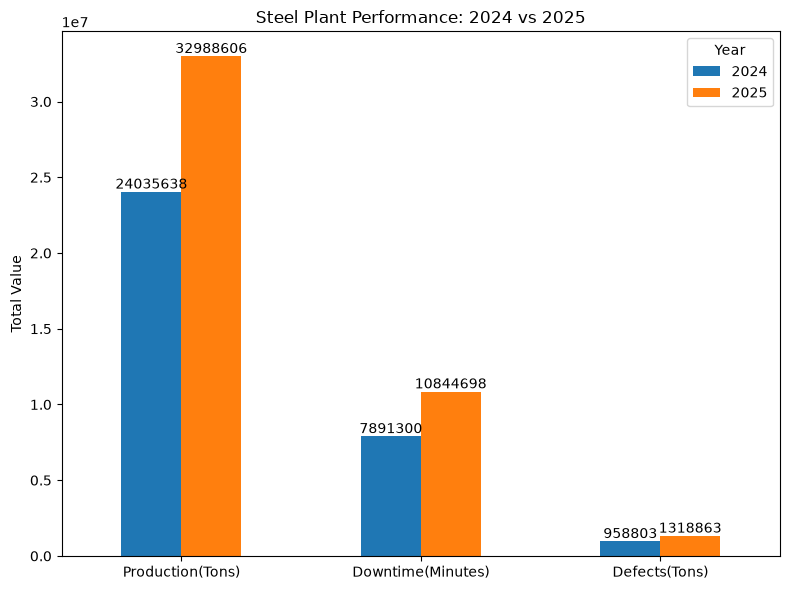

In [34]:
production_24 = df_2024["Production_Quantity_Tons"].sum()
downtime_24 = df_2024["Downtime_Minutes"].sum()
defects_24 = df_2024["Defect_Quantity_Tons"].sum()

production_25 = df_2025["Production_Quantity_Tons"].sum()
downtime_25 = df_2025["Downtime_Minutes"].sum()
defects_25 = df_2025["Defect_Quantity_Tons"].sum()

data = pd.DataFrame({
    "2024": [production_24, downtime_24, defects_24],
    "2025": [production_25, downtime_25, defects_25]
}, index=["Production(Tons)", "Downtime(Minutes)", "Defects(Tons)"])

ax = data.plot(kind="bar", figsize=(8,6))

plt.title("Steel Plant Performance: 2024 vs 2025")
plt.ylabel("Total Value")
plt.xticks(rotation=0)
plt.legend(title="Year")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

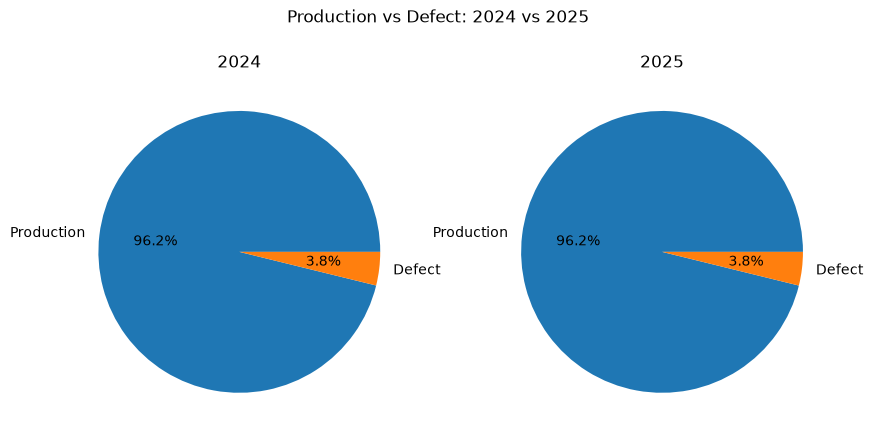

In [35]:
production_24 = df_2024["Production_Quantity_Tons"].sum()
defect_24 = df_2024["Defect_Quantity_Tons"].sum()

production_25 = df_2025["Production_Quantity_Tons"].sum()
defect_25 = df_2025["Defect_Quantity_Tons"].sum()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].pie(
    [production_24, defect_24],
    labels=["Production", "Defect"],
    autopct="%1.1f%%"
)
ax[0].set_title("2024")

ax[1].pie(
    [production_25, defect_25],
    labels=["Production", "Defect"],
    autopct="%1.1f%%"
)
ax[1].set_title("2025")

plt.suptitle("Production vs Defect: 2024 vs 2025")
plt.show()

   # ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Outlier Analysis</p>***

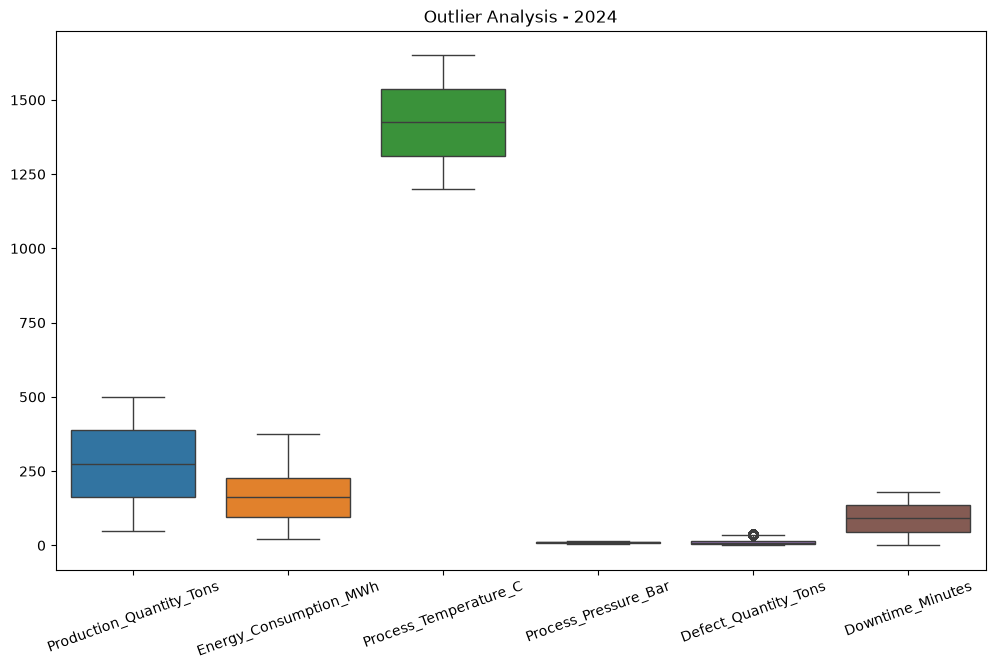

In [36]:
cols = [
    "Production_Quantity_Tons",
    "Energy_Consumption_MWh",
    "Process_Temperature_C",
    "Process_Pressure_Bar",
    "Defect_Quantity_Tons",
    "Downtime_Minutes"
]

plt.figure(figsize=(12, 7))

sns.boxplot(data=df_2024[cols])

plt.xticks(rotation=20)
plt.title("Outlier Analysis - 2024")
plt.show()

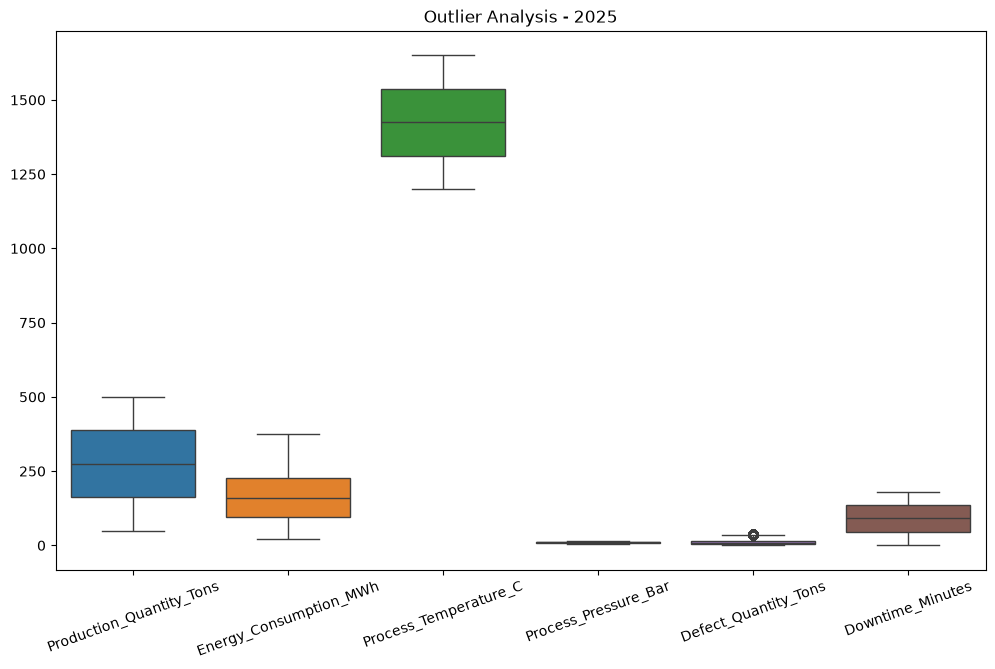

In [37]:
cols = [
    "Production_Quantity_Tons",
    "Energy_Consumption_MWh",
    "Process_Temperature_C",
    "Process_Pressure_Bar",
    "Defect_Quantity_Tons",
    "Downtime_Minutes"
]

plt.figure(figsize=(12, 7))

sns.boxplot(data=df_2025[cols])

plt.xticks(rotation=20)
plt.title("Outlier Analysis - 2025")
plt.show()

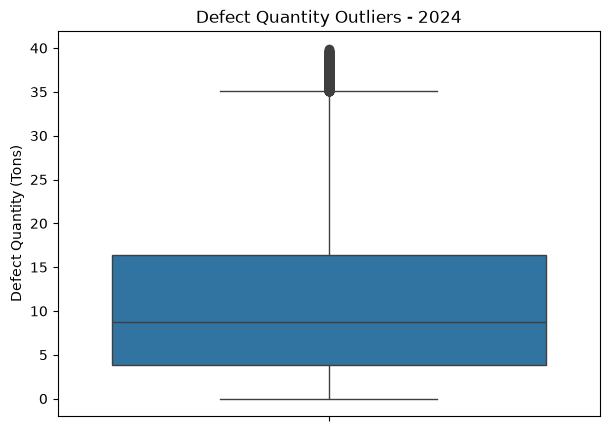

In [38]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df_2024["Defect_Quantity_Tons"])

plt.title("Defect Quantity Outliers - 2024")
plt.ylabel("Defect Quantity (Tons)")
plt.show()

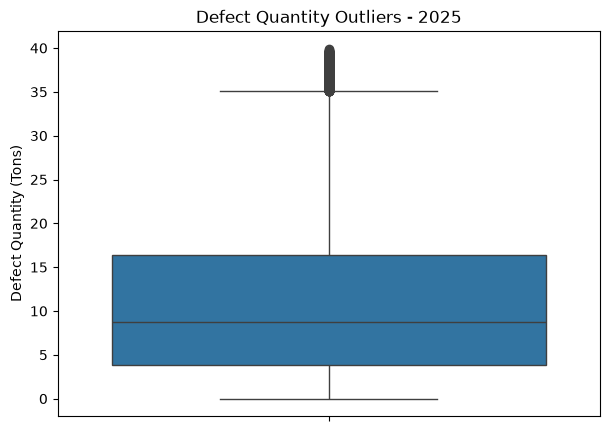

In [39]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df_2025["Defect_Quantity_Tons"])

plt.title("Defect Quantity Outliers - 2025")
plt.ylabel("Defect Quantity (Tons)")
plt.show()

In [95]:
# Combine 2024 and 2025 data
df = pd.concat([df_2024, df_2025], ignore_index=True)

# Calculate Q1 and Q3
Q1 = df['Defect_Quantity_Tons'].quantile(0.25)
Q3 = df['Defect_Quantity_Tons'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Print results
print("Q1:", Q1, "tons")
print("Q3:", Q3, "tons")
print("IQR:", IQR, "tons")
print("Lower Limit:", lower_limit, "tons")
print("Upper Limit:", upper_limit, "tons")
print("Outlier starts above:", upper_limit, "tons")

# Identify outliers
outliers = df[df['Defect_Quantity_Tons'] > upper_limit]

print("Total Outliers:", len(outliers))

Q1: 3.88 tons
Q3: 16.38 tons
IQR: 12.5 tons
Lower Limit: -14.870000000000001 tons
Upper Limit: 35.129999999999995 tons
Outlier starts above: 35.129999999999995 tons
Total Outliers: 1843


# ***MachineWise Outliers Analysis***

In [88]:
outliers = df[df['Defect_Quantity_Tons'] > 35.13]

machine_outliers = (
    outliers.groupby('Machine_ID')
    .agg(
        Outlier_Points=('Defect_Quantity_Tons', 'count'),
        Outlier_Tons=('Defect_Quantity_Tons', 'sum')
    )
    .sort_values('Outlier_Points', ascending=False)
)

machine_outliers.head(20)

,Outlier_Points,Outlier_Tons
Machine_ID,,
MCH-019,45,1658.86
MCH-056,45,1652.85
MCH-053,43,1591.42
MCH-022,43,1560.99
MCH-054,42,1547.52
MCH-058,40,1477.22
MCH-042,38,1390.36
MCH-034,38,1384.00
MCH-005,38,1382.53


# ***Opreator  Outliers Analysis***

In [89]:
operator_outliers = (
    outliers.groupby('Operator_ID')
    .agg(
        Outlier_Points=('Defect_Quantity_Tons', 'count'),
        Outlier_Tons=('Defect_Quantity_Tons', 'sum')
    )
    .sort_values('Outlier_Points', ascending=False)
)

operator_outliers.head(20)

,Outlier_Points,Outlier_Tons
Operator_ID,,
OP-109,12,442.60
OP-196,12,445.52
OP-108,11,406.79
OP-170,10,360.30
OP-071,10,360.66
OP-249,10,369.12
OP-462,10,364.43
OP-144,10,363.35
OP-532,10,371.70


# ***Shiftwise  Outliers Analysis***

In [90]:
# Shift-wise Defect Outlier Analysis

outliers = df[df['Defect_Quantity_Tons'] > 35.13]

shift_outliers = (
    outliers.groupby('Shift_Name')
    .agg(
        Outlier_Points=('Defect_Quantity_Tons', 'count'),
        Total_Outlier_Tons=('Defect_Quantity_Tons', 'sum')
    )
    .sort_values('Outlier_Points', ascending=False)
)

shift_outliers

,Outlier_Points,Total_Outlier_Tons
Shift_Name,,
A,625,22948.76
B,625,22917.80
C,586,21541.40


In [44]:
# Shift 2025

shift_defects = (
    df_2025[df_2025["Defect_Quantity_Tons"] > 25]
    .groupby("Shift_Name")
    .size()
    .reset_index(name="Times_Defect_Above_25_Tons")
    .sort_values("Times_Defect_Above_25_Tons", ascending=False)
)

shift_defects

,Shift_Name,Times_Defect_Above_25_Tons
1,B,3697
0,A,3591
2,C,3539


#  
# ***Conclusion***

# From the defect analysis of 2024 and 2025 combined data, some machines were found to generate more than **35tons of defect quantity repeatedly**.

# The shift-wise and operator-wise analysis was also performed to understand whether the higher defect values were concentrated in any particular shift or operator. The analysis helps to identify the machines where repeated high defect quantity is occurring.

# These machines should be **checked and investigated by the production and quality teams** to understand the possible reasons for higher defect generation. The investigation can include machine condition, maintenance history, production process, raw material quality, and operating conditions.

# The identified machines should not be considered as faulty only based on the outlier analysis. The outlier results are used as a **warning area for further investigation and monitoring**.
***

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Department-wise Analysis</p>***

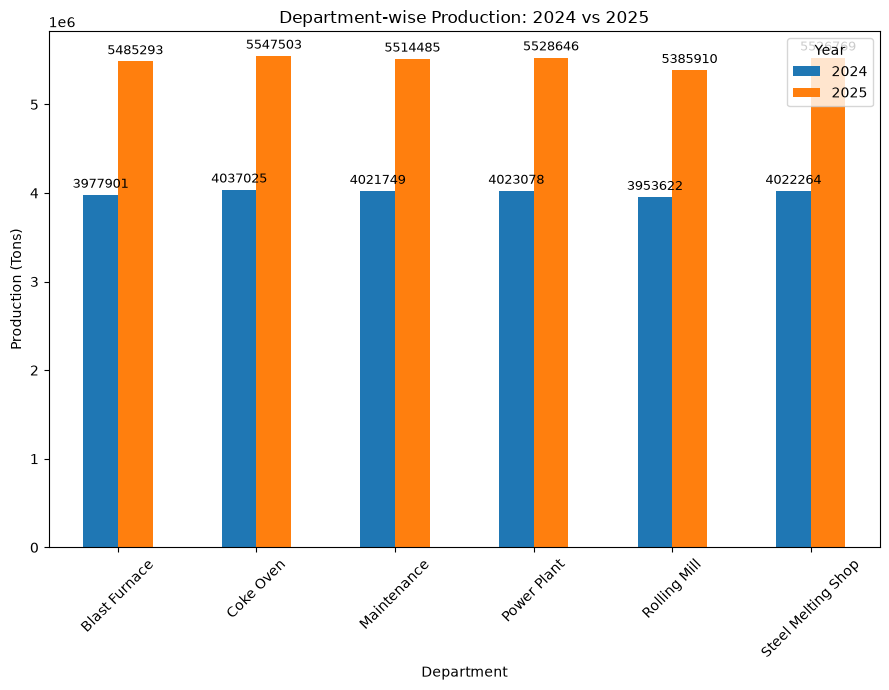

In [45]:
dept_2024 = (
    df_2024.groupby("Department_Name")["Production_Quantity_Tons"]
    .sum()
)

dept_2025 = (
    df_2025.groupby("Department_Name")["Production_Quantity_Tons"]
    .sum()
)

department_production = pd.DataFrame({
    "2024": dept_2024,
    "2025": dept_2025
})

ax = department_production.plot(
    kind="bar",
    figsize=(9, 7),
    title="Department-wise Production: 2024 vs 2025"
)

# Numbers on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.xlabel("Department")
plt.ylabel("Production (Tons)")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

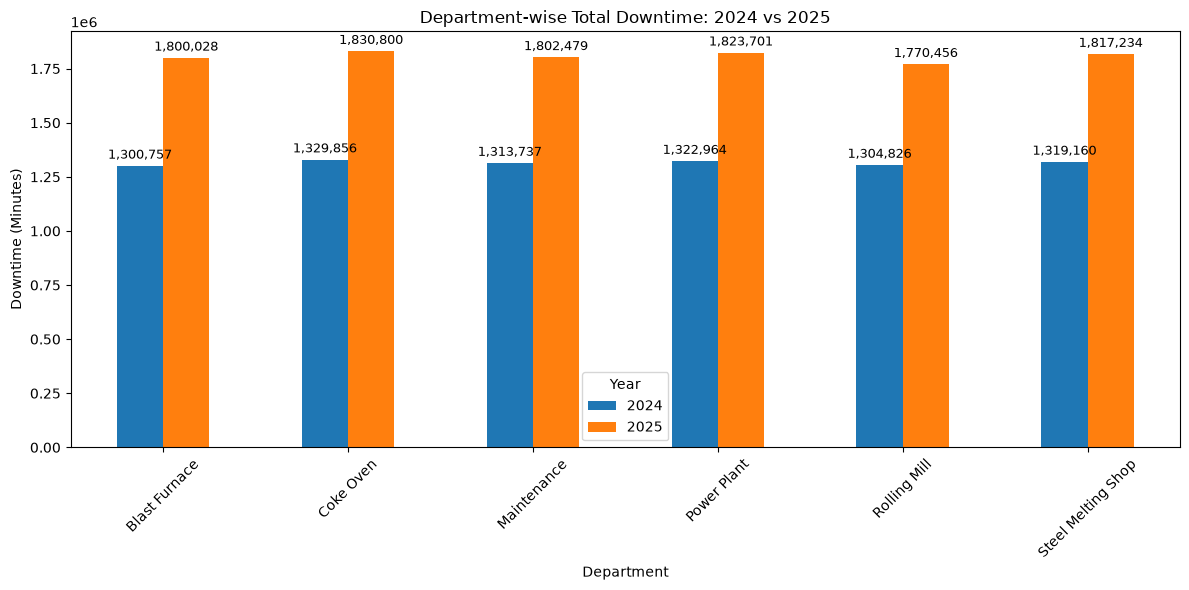

In [46]:
dept_downtime_2024 = (
    df_2024.groupby("Department_Name")["Downtime_Minutes"]
    .sum()
)

dept_downtime_2025 = (
    df_2025.groupby("Department_Name")["Downtime_Minutes"]
    .sum()
)

department_downtime = pd.DataFrame({
    "2024": dept_downtime_2024,
    "2025": dept_downtime_2025
})

ax = department_downtime.plot(
    kind="bar",
    figsize=(12, 6),
    title="Department-wise Total Downtime: 2024 vs 2025"
)

# Numbers on bars
for container in ax.containers:
    labels = [f"{bar.get_height():,.0f}" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.xlabel("Department")
plt.ylabel("Downtime (Minutes)")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

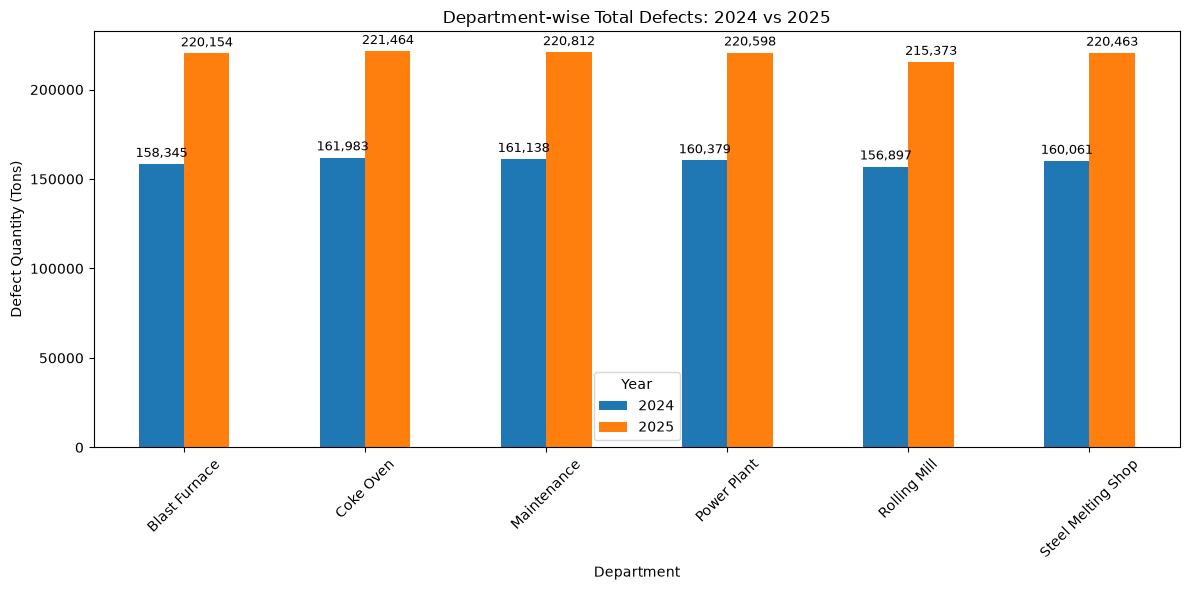

In [47]:
dept_defect_2024 = (
    df_2024.groupby("Department_Name")["Defect_Quantity_Tons"]
    .sum()
)

dept_defect_2025 = (
    df_2025.groupby("Department_Name")["Defect_Quantity_Tons"]
    .sum()
)

department_defect = pd.DataFrame({
    "2024": dept_defect_2024,
    "2025": dept_defect_2025
})

ax = department_defect.plot(
    kind="bar",
    figsize=(12, 6),
    title="Department-wise Total Defects: 2024 vs 2025"
)

# Numbers on bars
for container in ax.containers:
    labels = [f"{bar.get_height():,.0f}" for bar in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.xlabel("Department")
plt.ylabel("Defect Quantity (Tons)")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Shift-wise Analysis</p>***

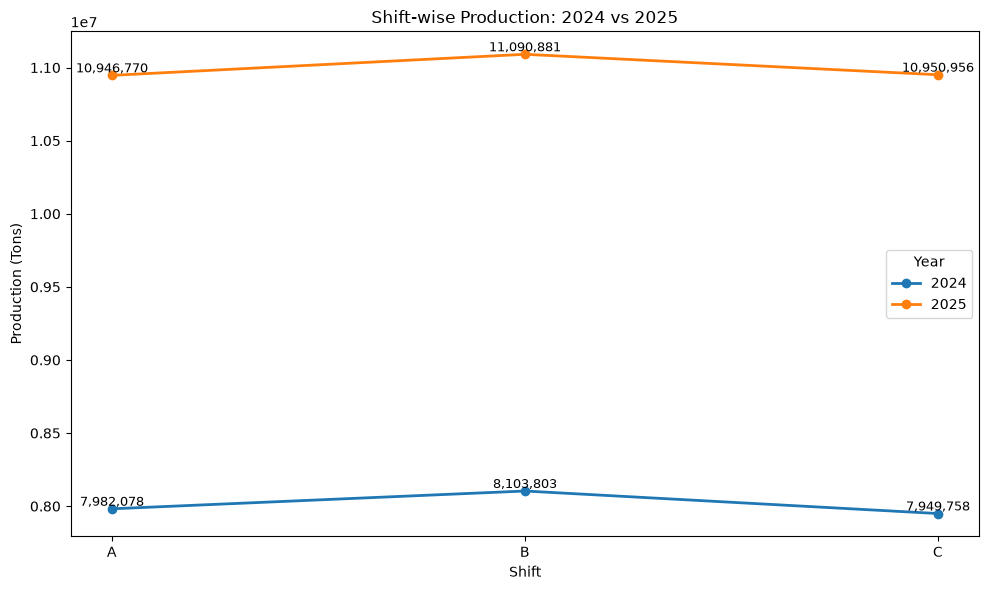

In [48]:
# 2024
shift_2024 = (
    df_2024.groupby("Shift_Name")["Production_Quantity_Tons"]
    .sum()
)

# 2025
shift_2025 = (
    df_2025.groupby("Shift_Name")["Production_Quantity_Tons"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.plot(
    shift_2024.index,
    shift_2024.values,
    marker="o",
    linewidth=2,
    label="2024"
)

plt.plot(
    shift_2025.index,
    shift_2025.values,
    marker="o",
    linewidth=2,
    label="2025"
)

# Numbers - 2024
for x, y in zip(shift_2024.index, shift_2024.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

# Numbers - 2025
for x, y in zip(shift_2025.index, shift_2025.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.title("Shift-wise Production: 2024 vs 2025")
plt.xlabel("Shift")
plt.ylabel("Production (Tons)")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Quality Analysis</p>***

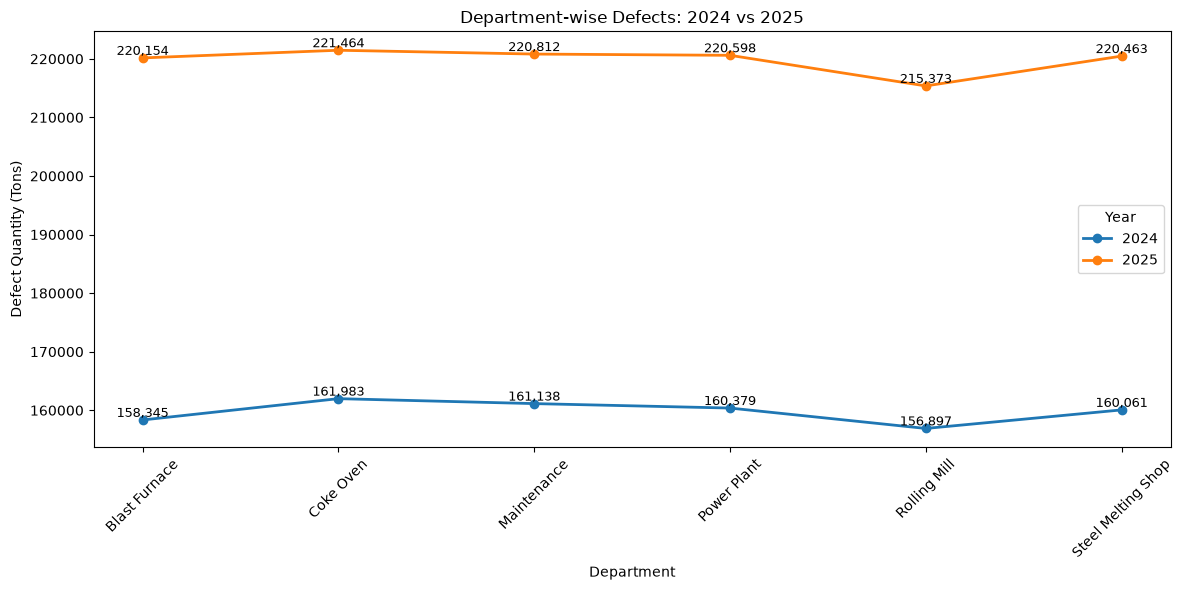

In [49]:
dept_defect_2024 = df_2024.groupby("Department_Name")["Defect_Quantity_Tons"].sum()
dept_defect_2025 = df_2025.groupby("Department_Name")["Defect_Quantity_Tons"].sum()

plt.figure(figsize=(12,6))

plt.plot(dept_defect_2024.index, dept_defect_2024.values,
         marker="o", linewidth=2, label="2024")

plt.plot(dept_defect_2025.index, dept_defect_2025.values,
         marker="o", linewidth=2, label="2025")

for x, y in zip(dept_defect_2024.index, dept_defect_2024.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

for x, y in zip(dept_defect_2025.index, dept_defect_2025.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.title("Department-wise Defects: 2024 vs 2025")
plt.xlabel("Department")
plt.ylabel("Defect Quantity (Tons)")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

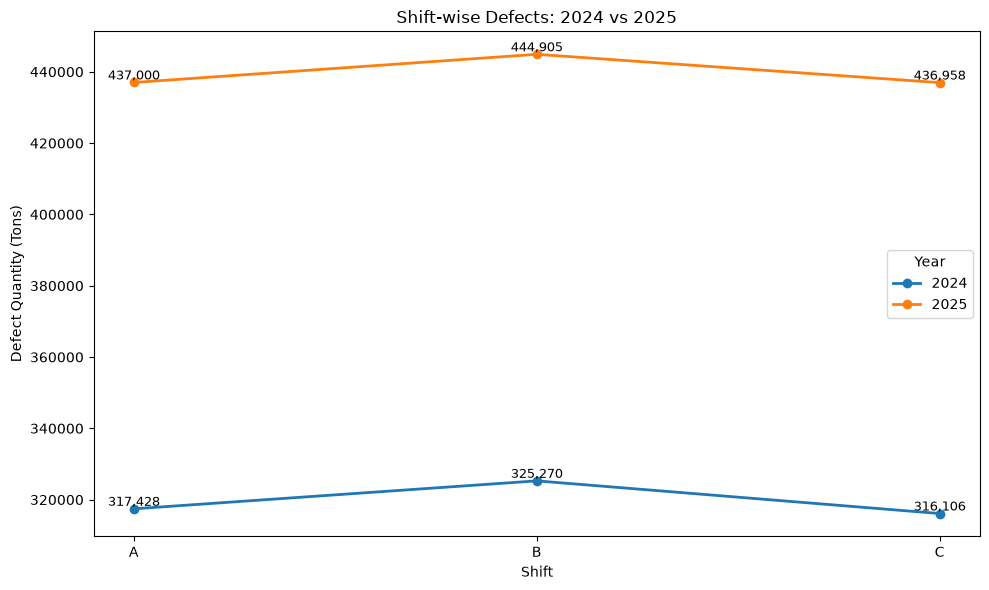

In [50]:
shift_defect_2024 = df_2024.groupby("Shift_Name")["Defect_Quantity_Tons"].sum()
shift_defect_2025 = df_2025.groupby("Shift_Name")["Defect_Quantity_Tons"].sum()

plt.figure(figsize=(10,6))

plt.plot(shift_defect_2024.index, shift_defect_2024.values,
         marker="o", linewidth=2, label="2024")

plt.plot(shift_defect_2025.index, shift_defect_2025.values,
         marker="o", linewidth=2, label="2025")

for x, y in zip(shift_defect_2024.index, shift_defect_2024.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

for x, y in zip(shift_defect_2025.index, shift_defect_2025.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.title("Shift-wise Defects: 2024 vs 2025")
plt.xlabel("Shift")
plt.ylabel("Defect Quantity (Tons)")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

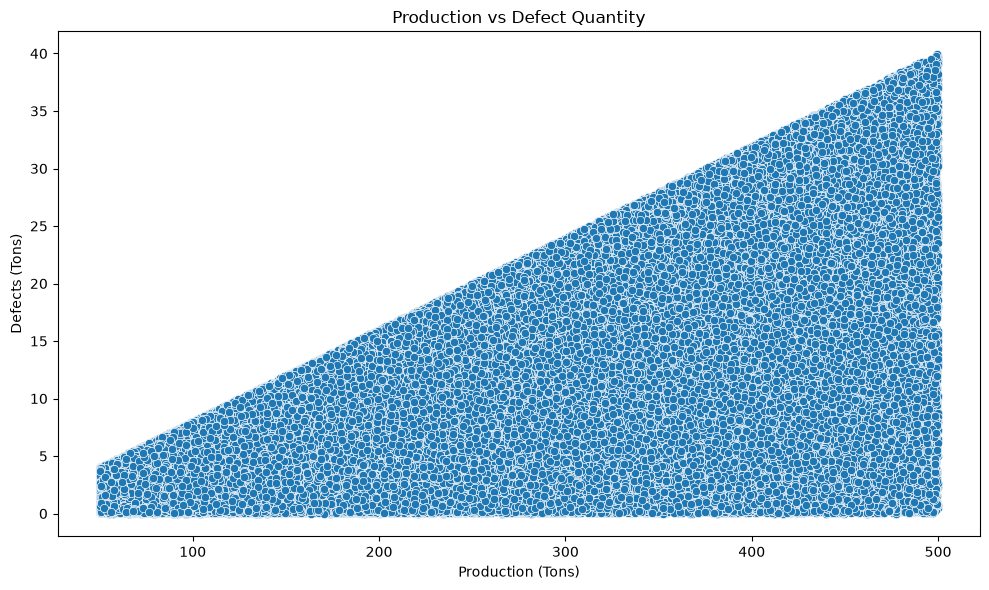

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Production_Quantity_Tons",
    y="Defect_Quantity_Tons"
)

plt.title("Production vs Defect Quantity")
plt.xlabel("Production (Tons)")
plt.ylabel("Defects (Tons)")
plt.tight_layout()
plt.show()

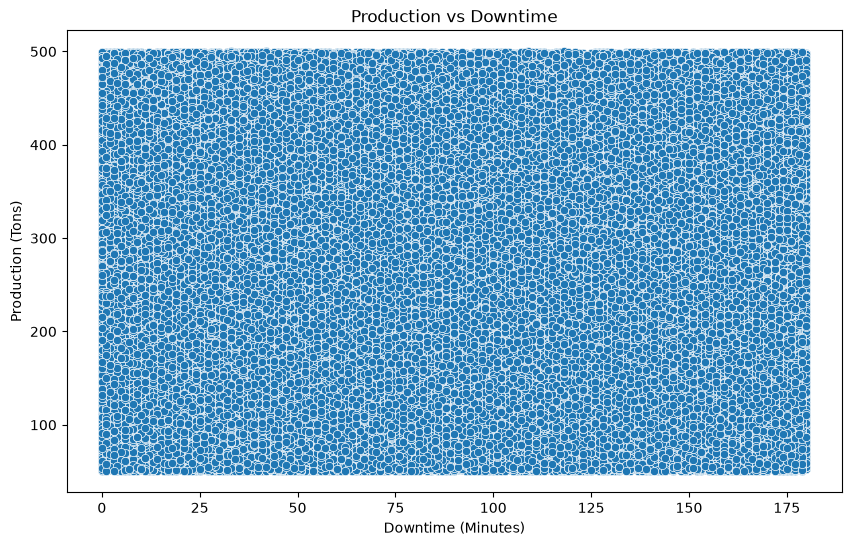

In [52]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Downtime_Minutes",
    y="Production_Quantity_Tons"
)

plt.title("Production vs Downtime")
plt.xlabel("Downtime (Minutes)")
plt.ylabel("Production (Tons)")

plt.show()

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Correlation Analysis </p>***

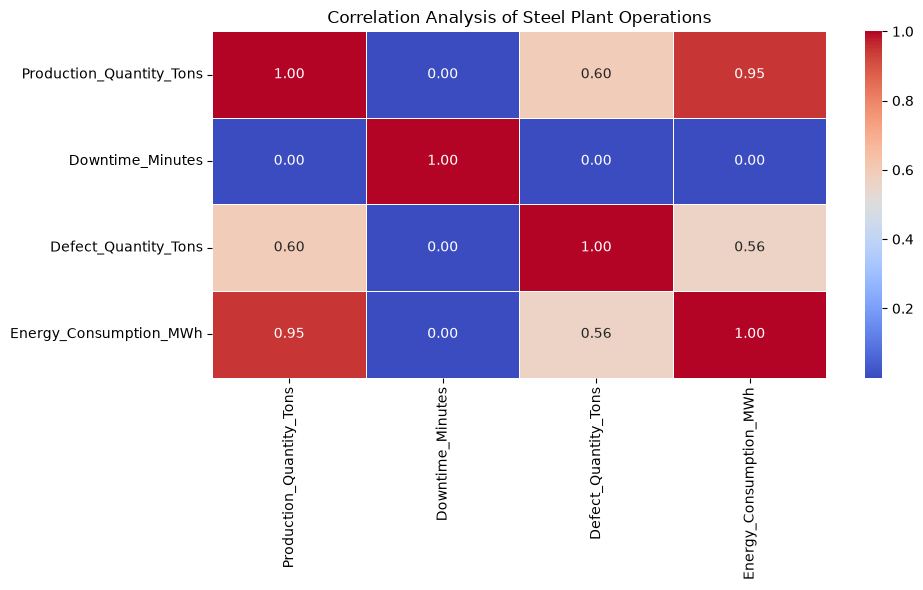

In [53]:
correlation_data = df[
    [
        "Production_Quantity_Tons",
        "Downtime_Minutes",
        "Defect_Quantity_Tons",
        "Energy_Consumption_MWh"
    ]
]

correlation_matrix = correlation_data.corr()


plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Analysis of Steel Plant Operations")
plt.tight_layout()
plt.show()

# ***Production ↑ → Energy Consumption ↑***
# ***Production ↑ → Defects ↑***
# ***Defects ↑ → Energy Consumption ↑***
# ***Downtime ↑ → No clear relationship with Production***
# ***Downtime ↑ → No clear relationship with Defects***
# ***Downtime ↑ → No clear relationship with Energy Consumption***

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;"> Monthly Production </p>***

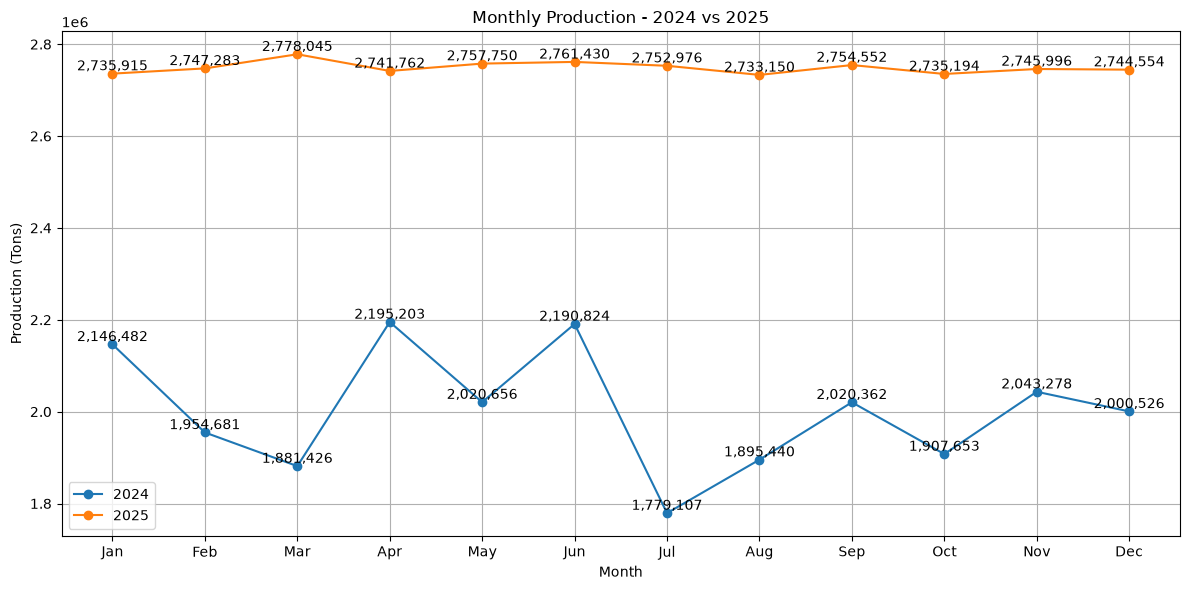

In [54]:
monthly_2024 = (
    df_2024.groupby(df_2024["Production_Date"].dt.month)["Production_Quantity_Tons"]
    .sum()
)

monthly_2025 = (
    df_2025.groupby(df_2025["Production_Date"].dt.month)["Production_Quantity_Tons"]
    .sum()
)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_2024.index,
    monthly_2024.values,
    marker="o",
    label="2024"
)

plt.plot(
    monthly_2025.index,
    monthly_2025.values,
    marker="o",
    label="2025"
)

for x, y in zip(monthly_2024.index, monthly_2024.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

for x, y in zip(monthly_2025.index, monthly_2025.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

plt.title("Monthly Production - 2024 vs 2025")
plt.xlabel("Month")
plt.ylabel("Production (Tons)")

plt.xticks(range(1, 13), months)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;">Top Problem Areas</p>***

In [55]:
high_downtime = (
    df.groupby(["Department_Name", "Machine_ID"])
    .agg(
        Total_Downtime=("Downtime_Minutes", "sum"),
        Total_Production=("Production_Quantity_Tons", "sum")
    )
    .sort_values(
        "Total_Downtime",
        ascending=False
    )
)

high_downtime.head(10)

,,Total_Downtime,Total_Production
Department_Name,Machine_ID,,
Maintenance,MCH-055,330117,982726.61
Coke Oven,MCH-027,328766,977719.30
Power Plant,MCH-045,327724,991483.23
Blast Furnace,MCH-004,325050,962781.54
Power Plant,MCH-046,322888,976947.82
Maintenance,MCH-053,322728,967766.59
Steel Melting Shop,MCH-016,322555,960879.63
Coke Oven,MCH-023,322440,950464.97
Power Plant,MCH-041,321888,955791.29


# ***High Defects***

In [56]:
high_defects = (
    df.groupby(["Department_Name", "Machine_ID"])
    .agg(
        Total_Defects=("Defect_Quantity_Tons", "sum"),
        Total_Production=("Production_Quantity_Tons", "sum")
    )
)

high_defects["Defect_Rate_%"] = (
    high_defects["Total_Defects"]
    / high_defects["Total_Production"]
    * 100
)

high_defects.sort_values(
    "Defect_Rate_%",
    ascending=False
).head(10)

Total_Defects  Total_Production  Defect_Rate_%
Department_Name    Machine_ID                                                
Power Plant        MCH-045          40506.87         991483.23       4.085482
Steel Melting Shop MCH-016          39111.68         960879.63       4.070404
Blast Furnace      MCH-005          38785.05         953044.92       4.069593
Maintenance        MCH-052          38349.49         943221.41       4.065799
                   MCH-054          37610.01         925428.46       4.064065
Rolling Mill       MCH-040          38229.62         941142.20       4.062045
Maintenance        MCH-059          39775.62         979272.62       4.061751
Coke Oven          MCH-026          38604.44         951236.71       4.058342
Rolling Mill       MCH-037          39319.18         969492.17       4.055647
Blast Furnace      MCH-009          38163.53         941378.99       4.054003

# ***Low Production***

In [57]:
low_production = (
    df.groupby(["Department_Name", "Machine_ID"])
    .agg(
        Total_Production=("Production_Quantity_Tons", "sum"),
        Total_Downtime=("Downtime_Minutes", "sum"),
        Total_Defects=("Defect_Quantity_Tons", "sum")
    )
    .sort_values(
        "Total_Production",
        ascending=True
    )
)

low_production.head(10)

Total_Production  Total_Downtime  Total_Defects
Department_Name    Machine_ID                                                 
Blast Furnace      MCH-007            905279.50          293076       36395.62
Rolling Mill       MCH-038            906259.40          307853       36216.04
                   MCH-031            917009.78          302904       36939.99
Steel Melting Shop MCH-018            917277.02          294910       36559.98
Power Plant        MCH-050            917316.59          307658       36278.03
Blast Furnace      MCH-008            918640.62          301603       37109.88
Rolling Mill       MCH-034            924959.52          302165       36508.83
Maintenance        MCH-054            925428.46          295833       37610.01
Blast Furnace      MCH-002            928076.43          313348       36672.16
Rolling Mill       MCH-035            929916.38          307141       37346.29

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;">Quality Status Analysis</p>***

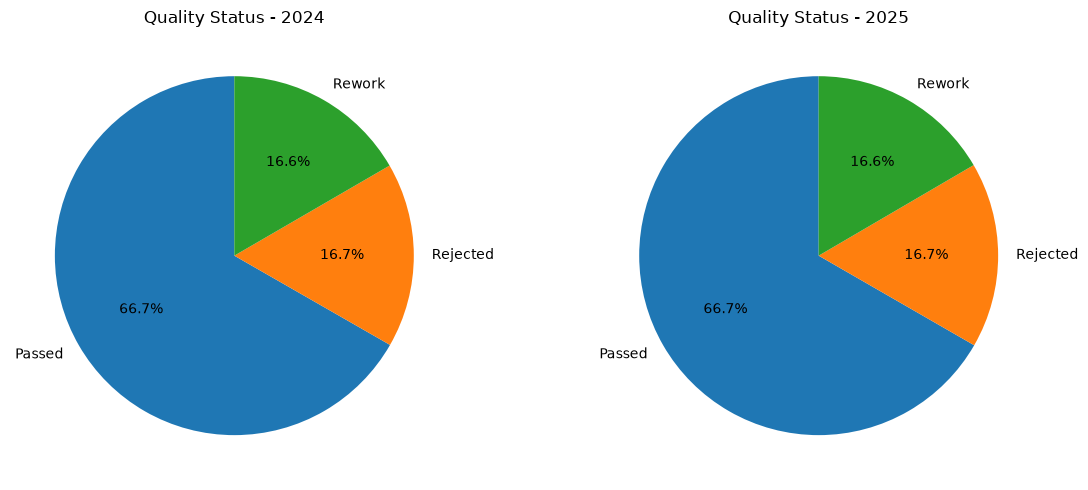

In [58]:
quality_2024 = df_2024["Quality_Status"].value_counts()
quality_2025 = df_2025["Quality_Status"].value_counts()

plt.figure(figsize=(12, 5))

# 2024
plt.subplot(1, 2, 1)

plt.pie(
    quality_2024,
    labels=quality_2024.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Quality Status - 2024")


# 2025
plt.subplot(1, 2, 2)

plt.pie(
    quality_2025,
    labels=quality_2025.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Quality Status - 2025")

plt.tight_layout()
plt.show()

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;">Energy Consumption Analysis</p>***

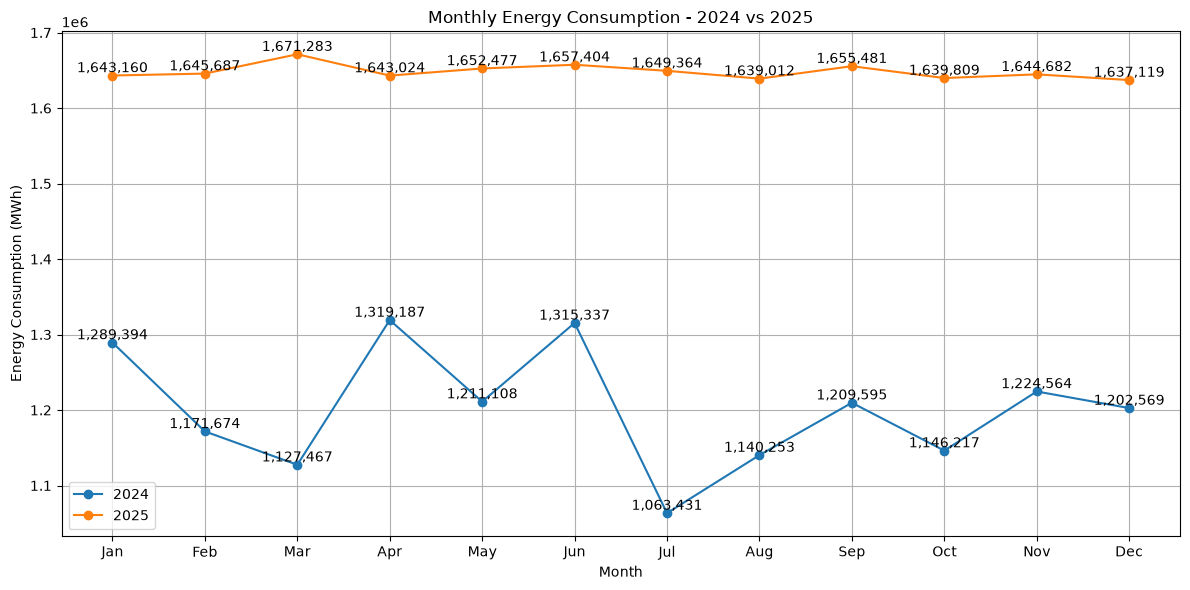

In [59]:
energy_2024 = (
    df_2024.groupby(df_2024["Production_Date"].dt.month)["Energy_Consumption_MWh"]
    .sum()
)

energy_2025 = (
    df_2025.groupby(df_2025["Production_Date"].dt.month)["Energy_Consumption_MWh"]
    .sum()
)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 6))

plt.plot(energy_2024.index, energy_2024.values, marker="o", label="2024")
plt.plot(energy_2025.index, energy_2025.values, marker="o", label="2025")
for x, y in zip(energy_2024.index, energy_2024.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

for x, y in zip(energy_2025.index, energy_2025.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

plt.title("Monthly Energy Consumption - 2024 vs 2025")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (MWh)")

plt.xticks(range(1, 13), months)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ***<P style="font-family:newtimeroman;font-size:150%;text-align:center;color:green; font-size: 70px;">Downtime Analysis</p>***

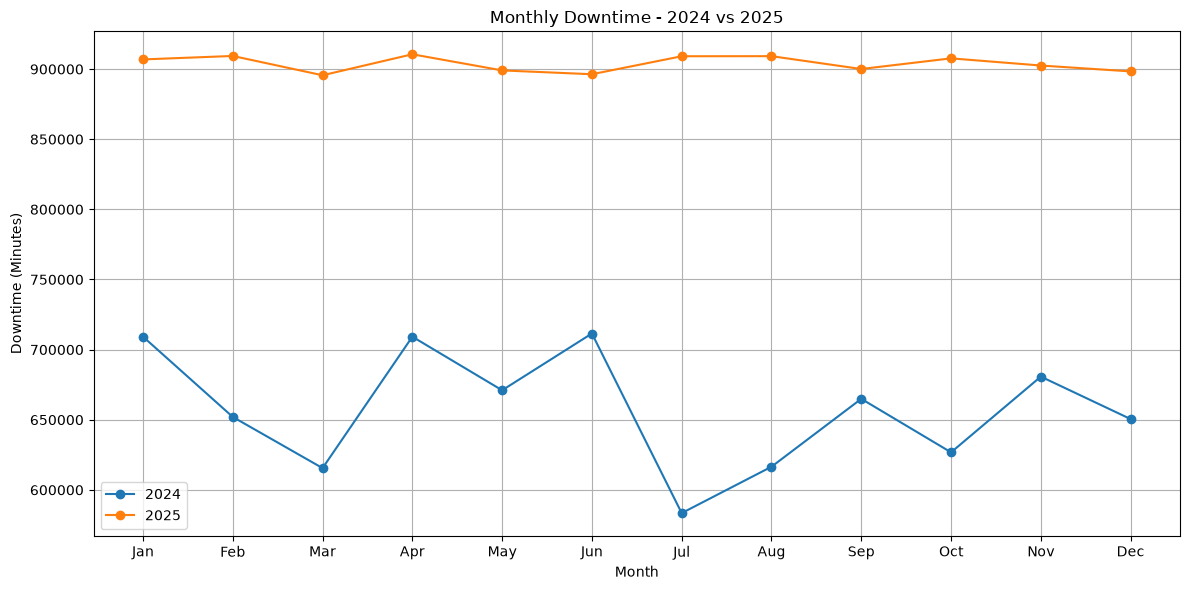

In [60]:
downtime_2024 = (
    df_2024.groupby(df_2024["Production_Date"].dt.month)["Downtime_Minutes"]
    .sum()
)

downtime_2025 = (
    df_2025.groupby(df_2025["Production_Date"].dt.month)["Downtime_Minutes"]
    .sum()
)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 6))

plt.plot(downtime_2024.index, downtime_2024.values,
         marker="o", label="2024")

plt.plot(downtime_2025.index, downtime_2025.values,
         marker="o", label="2025")

plt.title("Monthly Downtime - 2024 vs 2025")
plt.xlabel("Month")
plt.ylabel("Downtime (Minutes)")

plt.xticks(range(1, 13), months)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

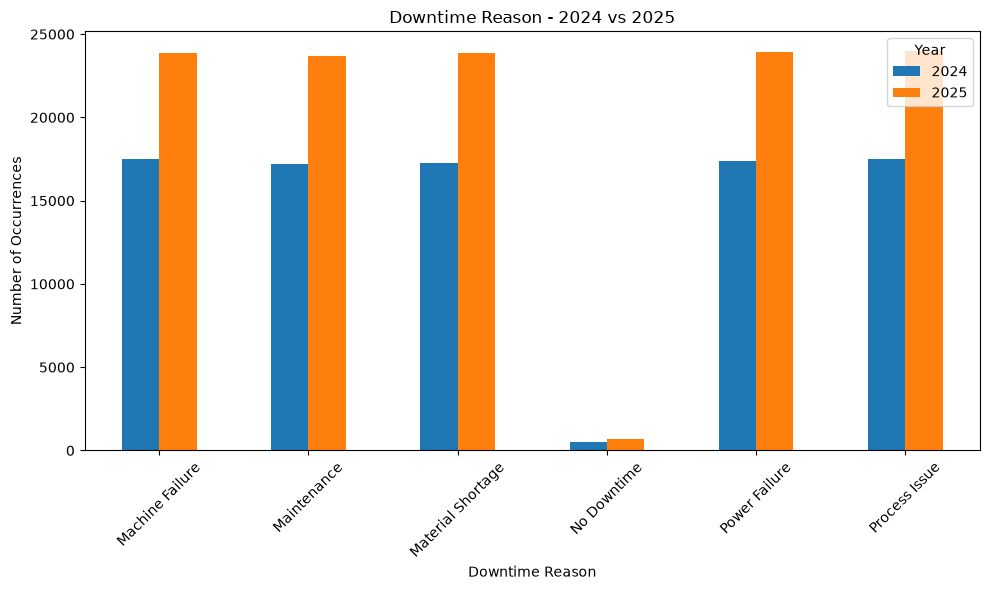

In [61]:
downtime_2024 = df_2024["Downtime_Reason"].value_counts()
downtime_2025 = df_2025["Downtime_Reason"].value_counts()

downtime_compare = pd.DataFrame({
    "2024": downtime_2024,
    "2025": downtime_2025
}).fillna(0)

downtime_compare.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Downtime Reason - 2024 vs 2025")
plt.xlabel("Downtime Reason")
plt.ylabel("Number of Occurrences")

plt.xticks(rotation=45)
plt.legend(title="Year")

plt.tight_layout()
plt.show()

# ***The EDA provided an overall understanding of the steel plant’s production and operational performance for 2024 and 2025. The analysis covered production, downtime, downtime reasons, energy consumption, defects, and quality status across departments, machines, shifts, and operators. Year-wise comparisons helped identify changes in production and operational patterns. Outlier analysis highlighted unusual production, downtime, and defect values that may require further investigation. Correlation analysis was used to understand the relationships between key operational factors. Overall, the analysis helps identify areas related to production efficiency, machine performance, downtime, energy usage, and quality that can be further investigated for operational improvement.***